# Logistic Regression

In [2]:
from PIL import Image
import pytesseract

# Path to the image file
image_path = r"D:\Piyush\Pictures\Question5.jpg"

# Load the image
image = Image.open(image_path)

# Perform OCR on the image
ocr_text = pytesseract.image_to_string(image)

# Print the extracted text
print(ocr_text)

Attempt to improve the performance of the Decision tree using the list of hyperparameters and their values given.
¢ Maximum depth: [5,10,15, None],
¢ criterion: ['gini', ‘entropy’,
¢ splitter: ['best’, 'random']

¢ Compare the recall values of the models built to find the best one

Which of the following statements is/are True?

A) The best model selects the value of max_depth as 10
B) The best model selects the value of criterion as ‘gini’
C) The best model selects the value of splitter as 'random'
D) The best model selects the value of splitter as 'best'

E) The best model selects the value of max_depth as 5

F) The best model selects the value of criterion as 'entropy'



In [3]:
from PIL import Image
import pytesseract

# Path to the image file
image_path = r"D:\Piyush\Pictures\LogisticRegressionProblemStatement.jpg"

# Load the image
image = Image.open(image_path)

# Perform OCR on the image
ocr_text = pytesseract.image_to_string(image)

# Print the extracted text
print(ocr_text)

Problem Statement:

Low back pain is a major cause of morbidity in the developed world, affecting 40% of people at some point in their lives. Back pain can be caused by a variety of problems with any parts of the complex,
interconnected network of spinal muscles, nerves, bones, discs, or tendons in the lumbar spine.

An irritation or problem with any of these structures can cause lower back pain and/or pain that radiates or is referred to other parts of the body. Many lower back problems also cause back muscle spasms,
which don't sound like much but can cause severe pain and disability.

While lower back pain is extremely common, the symptoms and severity of lower back pain vary greatly.

The spine of each patient was classified as - normal or abnormal, by practitioners, using the collected physical spine details/data.
Attribute information: -

(Please Note: Medical knowledge is not important to answer the questions in the quiz)

1. Pelvic_incidence: angle between a line perpendicular 

In [4]:
import pandas as pd

# Load the backpain.csv file
backpain_data = pd.read_csv(r'D:\Piyush\Downloads\backpain.csv')

# Display the first few rows of the dataset
print(backpain_data.head())

   pelvic_incidence  pelvic tilt  lumbar_lordosis_angle  sacral_slope  \
0         63.027817    22.552586              39.609117     40.475232   
1         39.056951    10.060991              25.015378     28.995960   
2         68.832021    22.218482              50.092194     46.613539   
3         69.297008    24.652878              44.311238     44.644130   
4         49.712859     9.652075              28.317406     40.060784   

   pelvic_radius  degree_spondylolisthesis  pelvic_slope  Direct_tilt  \
0      98.672917                 -0.254400      0.744503      12.5661   
1     114.405425                  4.564259      0.415186      12.8874   
2     105.985135                 -3.530317      0.474889      26.8343   
3     101.868495                 11.211523      0.369345      23.5603   
4     108.168725                  7.918501      0.543360      35.4940   

   thoracic_slope  cervical_tilt  sacrum_angle  scoliosis_slope    Status  
0         14.5386       15.30468    -28.658501

In [9]:
# Filter variables with correlation >= 0.7 with 'pelvic_incidence'
correlated_vars = correlation_matrix['pelvic_incidence'][correlation_matrix['pelvic_incidence'] >= 0.7]
print(correlated_vars)

pelvic_incidence         1.000000
lumbar_lordosis_angle    0.717282
sacral_slope             0.814960
Name: pelvic_incidence, dtype: float64


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode the 'Status' variable
label_encoder = LabelEncoder()
backpain_data['Status'] = label_encoder.fit_transform(backpain_data['Status'])

# Split the data into features (X) and target (y)
X = backpain_data.drop(columns=['Status'])
y = backpain_data['Status']

# Split the data into training and testing sets (70:30 ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

# Calculate the percentage of 0 and 1 classes in y_test
class_distribution = y_test.value_counts(normalize=True) * 100
print(class_distribution)

Status
0    70.967742
1    29.032258
Name: proportion, dtype: float64


In [11]:
range_1 = y[y == 1].index.min(), y[y == 1].index.max()
range_0 = y[y == 0].index.min(), y[y == 0].index.max()

print("Range of 1:", range_1)
print("Range of 0:", range_0)

Range of 1: (210, 309)
Range of 0: (0, 209)


piyushkapadia: Which metric is most appropriate to evaluate the model according to this Problem Statement -
Problem Statement:

Low back pain is a major cause of morbidity in the developed world, affecting 40% of people at some point in their lives. Back pain can be caused by a variety of problems with any parts of the complex,
interconnected network of spinal muscles, nerves, bones, discs, or tendons in the lumbar spine.

An irritation or problem with any of these structures can cause lower back pain and/or pain that radiates or is referred to other parts of the body. Many lower back problems also cause back muscle spasms,
which don't sound like much but can cause severe pain and disability.

While lower back pain is extremely common, the symptoms and severity of lower back pain vary greatly.

The spine of each patient was classified as - normal or abnormal, by practitioners, using the collected physical spine details/data.

GitHub Copilot: Based on the problem statement, the task is a binary classification problem where the spine of each patient is classified as "normal" or "abnormal." Since the dataset involves medical diagnosis, the most appropriate metric to evaluate the model would be **F1-score**.

The F1-score is particularly suitable because:
1. It balances precision and recall, which is crucial in medical diagnosis to avoid false negatives (misclassifying an abnormal spine as normal) and false positives (misclassifying a normal spine as abnormal).
2. It is effective when the dataset is imbalanced, which is often the case in medical datasets.

If the dataset is balanced, **accuracy** can also be considered, but F1-score remains the preferred metric for medical applications.

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score

# Initialize the logistic regression model
logistic_model = LogisticRegression(random_state=1)

# Fit the model on the training data
logistic_model.fit(X_train, y_train)

# Predict on the training set
y_train_pred = logistic_model.predict(X_train)

# Calculate the recall on the training set
recall_train = recall_score(y_train, y_train_pred)
print("Recall on training set:", recall_train)

Recall on training set: 0.7808219178082192


d:\Dev\Tools\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [14]:
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix for the training data
conf_matrix = confusion_matrix(y_train, y_train_pred)

# Extract FN and FP values
FN = conf_matrix[1, 0]  # False Negatives: Actual 1, Predicted 0
FP = conf_matrix[0, 1]  # False Positives: Actual 0, Predicted 1

print("Confusion Matrix:")
print(conf_matrix)
print("False Negatives (FN):", FN)
print("False Positives (FP):", FP)

Confusion Matrix:
[[126  18]
 [ 16  57]]
False Negatives (FN): 16
False Positives (FP): 18


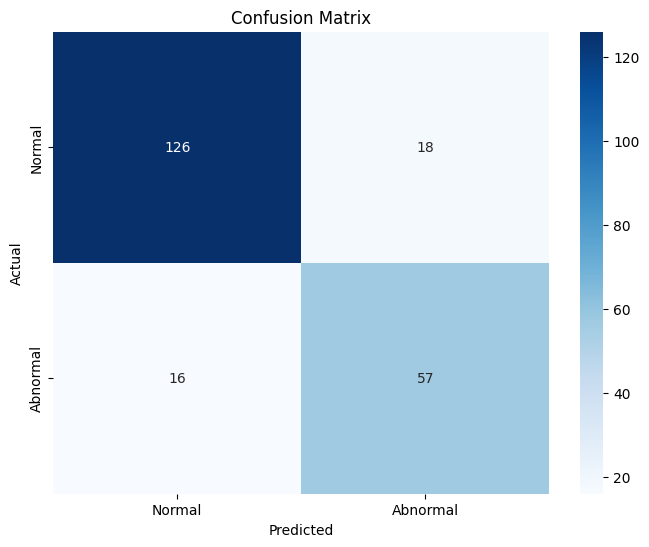

In [15]:
import seaborn as sns

import matplotlib.pyplot as plt

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Abnormal'], yticklabels=['Normal', 'Abnormal'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [18]:
# Initialize the logistic regression model with solver 'liblinear' and random_state=1
logistic_model_liblinear = LogisticRegression(solver='liblinear', random_state=1)

# Fit the model on the training data
logistic_model_liblinear.fit(X_train, y_train)

# Predict on the training set
y_train_pred_liblinear = logistic_model_liblinear.predict(X_train)

# Print the model coefficients
print("Model coefficients:", logistic_model_liblinear.coef_) 
# Calculate the recall on the training set for the 'liblinear' solver
recall_train_liblinear = recall_score(y_train, y_train_pred_liblinear)
print("Recall on training set (liblinear):", recall_train_liblinear)

Model coefficients: [[-0.03513246 -0.08802729  0.03800013  0.05289484  0.02342797 -0.13743714
  -0.23875619 -0.00521902  0.0164683  -0.08654235  0.0022453   0.00108345]]
Recall on training set (liblinear): 0.7671232876712328


In [19]:
# Predict on the test set
y_test_pred = logistic_model.predict(X_test)

# Identify false negatives (actual 1, predicted 0)
false_negatives_indices = y_test[(y_test == 1) & (y_test_pred == 0)].index

# Get the range of false negatives
false_negatives_range = false_negatives_indices.min(), false_negatives_indices.max()
print("Range of false negatives:", false_negatives_range)

Range of false negatives: (244, 302)


The accuracy of a model is calculated as:

\[
\text{Accuracy} = \frac{\text{Number of Correct Predictions}}{\text{Total Number of Predictions}}
\]

In this case:
- Total number of people = \(10^5 = 100,000\)
- Number of people with abnormal spine = 100
- Number of people classified as normal = \(10^5 = 100,000\)
- Number of correct predictions = \(10^5 - 100 = 99,900\) (all normal predictions are correct since no abnormal cases are predicted correctly)

Thus, the accuracy is:

\[
\text{Accuracy} = \frac{99,900}{100,000} = 0.999 = 99.9\%
\]

The accuracy of the model is **99.9%**.

In [24]:
import pandas as pd

# Load the backpain.csv file
nc_data = pd.read_csv(r'D:\Piyush\Downloads\Nutrient Composition Dataset.csv')

# Display the first few rows of the dataset
print(nc_data.head())

   S.No   Protein       Fat  vitaminC     Fibre  \
0     1  0.452369  1.170926  1.079271  1.702960   
1     2  2.321087  0.706856  0.350088  0.658249   
2     3  0.884554  1.186571  2.428544  1.984562   
3     4  0.715501  0.577599  0.270925  0.369266   
4     5  0.132610  0.544521  0.116884  0.557309   

                                             Product  
0  Amaranth leaves, cooked, boiled, drained, with...  
1                              Bacon and beef sticks  
2  Apples, frozen, unsweetened, unheated (Include...  
3         Alcoholic beverage, beer, light, BUD LIGHT  
4               Alcoholic beverage, daiquiri, canned  


In [22]:
from PIL import Image
import pytesseract

# Path to the image file
image_path = r"D:\Piyush\Pictures\LogisticRegressionProblemStatement.jpg"

# Load the image
image = Image.open(image_path)

# Perform OCR on the image
ocr_text = pytesseract.image_to_string(image)

# Print the extracted text
print(ocr_text)

Problem Statement:

Low back pain is a major cause of morbidity in the developed world, affecting 40% of people at some point in their lives. Back pain can be caused by a variety of problems with any parts of the complex,
interconnected network of spinal muscles, nerves, bones, discs, or tendons in the lumbar spine.

An irritation or problem with any of these structures can cause lower back pain and/or pain that radiates or is referred to other parts of the body. Many lower back problems also cause back muscle spasms,
which don't sound like much but can cause severe pain and disability.

While lower back pain is extremely common, the symptoms and severity of lower back pain vary greatly.

The spine of each patient was classified as - normal or abnormal, by practitioners, using the collected physical spine details/data.
Attribute information: -

(Please Note: Medical knowledge is not important to answer the questions in the quiz)

1. Pelvic_incidence: angle between a line perpendicular 

In [23]:
from PIL import Image
import pytesseract

# Path to the image file
image_path = r"D:\Piyush\Pictures\K-Means-Clustring-HandsOn.jpg"

# Load the image
image = Image.open(image_path)

# Perform OCR on the image
ocr_text = pytesseract.image_to_string(image)

# Print the extracted text
print(ocr_text)

Instructions “A

Please download and import the dataset Nutrient Composition Dataset.csv into Jupyter Notebook to attempt this quiz.

Problem Statment:

HealthifyUs is a US-based startup company that gives nutrition advice to its customers to help them stay healthy and fit. They have collected data about various food items sold in the market along with
their nutrient composition. The data contains information about the amount of the following nutrients in food items - Protein, Fat, Vitamin C, and Fibre. The food items can be segmented based on their
nutrient composition so that suggestions can be provided based on the customer's nutrition requirements.

Attribute information:

1. Protein: protein content in the food products

2. Fat: fat content in the food products

3. vitaminC: vitamin C content in the food products
4. Fibre: Fibre content in the food products

5. Product: Name of the food products

Kindly go through these guidelines before you attempt the quiz.

1. Use random_state=

In [ ]:

Hands-on Quiz - Linear Regression

In [25]:
# Drop the 'S.No' column
nc_data = nc_data.drop(columns=['S.No'])

# Calculate the IQR of the 'Protein' variable
Q1 = nc_data['Protein'].quantile(0.25)  # First quartile (25th percentile)
Q3 = nc_data['Protein'].quantile(0.75)  # Third quartile (75th percentile)
IQR = Q3 - Q1  # Interquartile Range

print("Interquartile Range (IQR) of Protein:", IQR)

Interquartile Range (IQR) of Protein: 0.8592526325000001


In [26]:
from scipy.stats import skew

# Calculate the skewness of the 'Fat' variable
fat_skewness = skew(nc_data['Fat'])
print("Skewness of 'Fat':", fat_skewness)

# Check if it is left-skewed
if fat_skewness < 0:
    print("The 'Fat' variable has a left-skewed distribution.")
else:
    print("The 'Fat' variable does not have a left-skewed distribution.")

Skewness of 'Fat': 0.8375338565362704
The 'Fat' variable does not have a left-skewed distribution.


In [30]:
# Compute the correlation matrix
correlation_matrix_nc = nc_data.select_dtypes(include=['float64', 'int64']).corr()

# Find the pair of variables with the highest correlation by magnitude
correlation_matrix_nc_unstacked = correlation_matrix_nc.abs().unstack()
correlation_matrix_nc_unstacked = correlation_matrix_nc_unstacked[correlation_matrix_nc_unstacked < 1]  # Exclude self-correlation
highest_corr_pair_nc = correlation_matrix_nc_unstacked.idxmax()
highest_corr_value_nc = correlation_matrix_nc_unstacked.max()

print("Pair of variables with the highest correlation by magnitude:", highest_corr_pair_nc)
print("Highest correlation value:", highest_corr_value_nc)

Pair of variables with the highest correlation by magnitude: ('Protein', 'Fat')
Highest correlation value: 0.38231167979368924


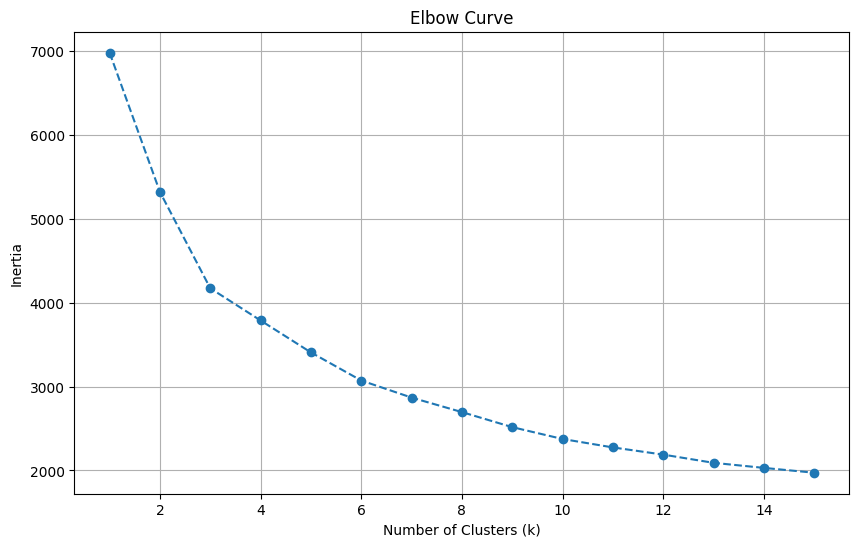

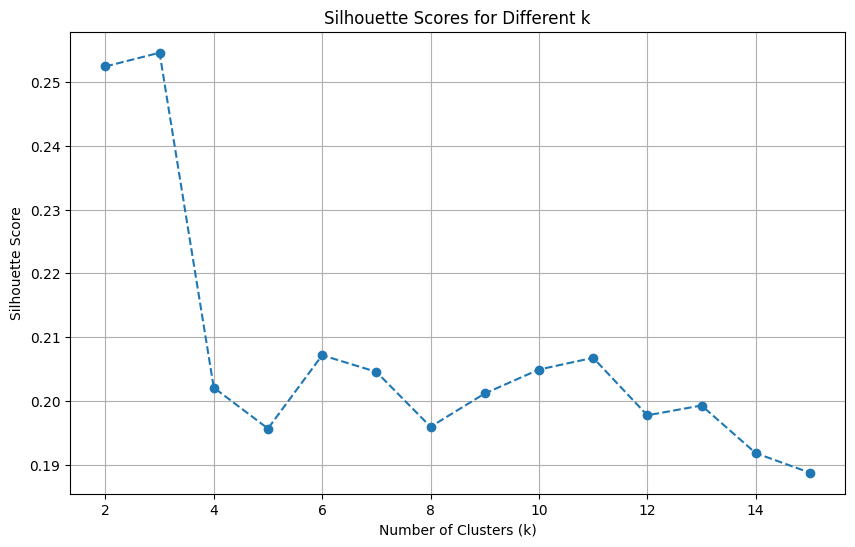

Silhouette Scores: [None, 0.25241844825818016, 0.25457085564593496, 0.20209788371115694, 0.1956911786030402, 0.2071766029811893, 0.2045687931159596, 0.19596389627440364, 0.20117953507818484, 0.20493317387242002, 0.20677161338867206, 0.19776376721094044, 0.19929839529966792, 0.19183239882288844, 0.18876717468712004]


In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt

# Scale the numerical variables using z-score scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(nc_data[['Protein', 'Fat', 'vitaminC', 'Fibre']])

# Initialize lists to store inertia and silhouette scores
inertia = []
silhouette_scores = []

# Range of k values to test
k_values = range(1, 16)

# Apply K-means for each k and calculate inertia and silhouette scores
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=1)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)
    
    # Calculate silhouette score only for k > 1
    if k > 1:
        silhouette_scores.append(silhouette_score(scaled_data, kmeans.labels_))
    else:
        silhouette_scores.append(None)

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_values, inertia, marker='o', linestyle='--')
plt.title('Elbow Curve')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid()
plt.show()

# Plot silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(k_values[1:], silhouette_scores[1:], marker='o', linestyle='--')
plt.title('Silhouette Scores for Different k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid()
plt.show()

# Determine the appropriate value of k from the elbow curve and silhouette scores
print("Silhouette Scores:", silhouette_scores)

In [32]:
# Apply K-means clustering with 3 clusters
kmeans_3_clusters = KMeans(n_clusters=3, random_state=1)
kmeans_3_clusters.fit(scaled_data)

# Count the number of observations in the 2nd cluster (cluster index 1)
second_cluster_count = sum(kmeans_3_clusters.labels_ == 1)
print("Number of observations in the 2nd cluster:", second_cluster_count)

Number of observations in the 2nd cluster: 444
